# Missing Data Imputation for Multivariate SuSiE

This notebook demonstrates variational imputation for handling missing entries in
the multivariate response matrix Y when R > 1. The approach integrates missing data
handling directly into the IBSS loop via a variational EM strategy:

- **E-step**: Impute missing Y entries using the conditional normal distribution
  given observed entries and current fitted values.
- **M-step**: Proceed with SuSiE's standard IBSS updates as if data were complete.

The key identity shows this produces exactly the complete-data ELBO plus
correction terms for imputation uncertainty.

## 1. Problem Setup

Generate multivariate SuSiE data with N=200 observations, J=500 predictors,
R=3 conditions, and L=3 true causal effects.

In [1]:
library(mvsusieR)
library(MASS)
set.seed(42)

N <- 200; J <- 500; R <- 3; L <- 3
X <- matrix(rnorm(N * J), N, J)

# True effects
causal <- c(50, 150, 300)
B <- matrix(0, J, R)
B[causal[1], ] <- c(1.5, 0.5, 0)
B[causal[2], ] <- c(0, 1.0, 1.2)
B[causal[3], ] <- c(0.8, 0.8, 0.8)

# True residual covariance
V_true <- matrix(c(1, 0.3, 0.2,  0.3, 1.5, 0.1,  0.2, 0.1, 0.8), R, R)
E <- mvrnorm(N, rep(0, R), V_true)
Y_full <- X %*% B + E

cat("Data dimensions: N =", N, ", J =", J, ", R =", R, "\n")
cat("True causal variables:", causal, "\n")

Loading required package: mashr

Loading required package: ashr

Loading required package: susieR



Data dimensions: N = 200 , J = 500 , R = 3 
True causal variables: 50 150 300 


## 2. Introduce Missing Data

Apply MCAR (Missing Completely At Random) at a 20% rate.

In [2]:
miss_rate <- 0.20
miss_mask <- matrix(runif(N * R) < miss_rate, N, R)
Y_miss <- Y_full
Y_miss[miss_mask] <- NA

cat("Missing rate:", mean(is.na(Y_miss)), "\n")
cat("Missing entries per condition:\n")
print(colSums(is.na(Y_miss)))

Missing rate: 0.1966667 


Missing entries per condition:


[1] 41 36 41


## 3. Mathematical Derivation

### Conditional Normal Imputation

For observation $i$ with missing set $M_i$ and observed set $O_i$, let
$\Lambda = V^{-1}$ (precision matrix). The conditional distribution of
missing given observed entries is:

$$E[Y_{i,M} | Y_{i,O}] = \mu_{i,M} - \Lambda_{MM}^{-1} \Lambda_{MO} (Y_{i,O} - \mu_{i,O})$$

$$\text{Var}[Y_{i,M} | Y_{i,O}] = \Lambda_{MM}^{-1}$$

where $\mu_i$ is the current fitted value (sum of all L posterior mean effects).

### Accumulated Imputation Covariance

$$Y_{\text{cov}} = \sum_i \text{Var}[Y_{i,M} | Y_{i,O}]$$

is an R x R matrix accumulated across all observations, where each observation
contributes $\Lambda_{M_i,M_i}^{-1}$ to the $(M_i, M_i)$ block.

### ELBO Correction

The complete-data ELBO is corrected for imputation uncertainty:

$$\text{ELBO}_{\text{miss}} = \text{ELBO}_{\text{complete}} - \frac{1}{2} \text{tr}(V^{-1} Y_{\text{cov}}) - \sum_i H(q(Y_{i,M}))$$

where the negative entropy term is:

$$H(q(Y_{i,M})) = \frac{1}{2}\left(|M_i| \log\frac{1}{2\pi e} + \log|\Lambda_{M_i,M_i}|\right)$$

### Residual Variance Update

$$V = \frac{1}{n}\left(\hat{R}^T\hat{R} + \text{var\_part\_ERSS} + Y_{\text{cov}}\right)$$

where the additional $Y_{\text{cov}} / n$ term accounts for the uncertainty
in imputed values.

## 4. Step-by-Step Imputation

Demonstrate the imputation pipeline on a small subset.

In [3]:
# Work with a small example
Y_small <- Y_miss[1:20, ]
mu_small <- matrix(0, 20, R)  # Initial fitted values = 0

# Step 1: Extract missingness patterns
Y_missing_small <- is.na(Y_small)
Y_small[Y_missing_small] <- 0  # Zero-fill for computation

miss_info <- mvsusieR:::extract_missing_patterns(Y_missing_small)
cat("Number of unique missingness patterns:", miss_info$n_patterns, "\n")
for (k in seq_len(miss_info$n_patterns)) {
  cat("  Pattern", k, ":", which(miss_info$patterns[[k]]),
      "- applies to", length(miss_info$pattern_obs[[k]]), "observations\n")
}

Number of unique missingness patterns: 4 


  Pattern 1 : 3 - applies to 2 observations
  Pattern 2 : 2 - applies to 4 observations
  Pattern 3 : 1 - applies to 2 observations
  Pattern 4 : 1 2 - applies to 1 observations


In [4]:
# Step 2: Precompute pattern cache (Cholesky of Lambda_MM per pattern)
Vinv <- solve(V_true)
pattern_cache <- mvsusieR:::precompute_pattern_cache(Vinv, miss_info$patterns)

cat("Cache for each pattern:\n")
for (k in seq_along(pattern_cache)) {
  pc <- pattern_cache[[k]]
  cat("  Pattern", k, ": miss =", pc$miss, ", n_miss =", pc$n_miss,
      ", neg_ent =", round(pc$neg_ent, 3), "\n")
}

Cache for each pattern:


  Pattern 1 : miss = 3 , n_miss = 1 , neg_ent = -1.281 
  Pattern 2 : miss = 2 , n_miss = 1 , neg_ent = -1.59 
  Pattern 3 : miss = 1 , n_miss = 1 , neg_ent = -1.366 
  Pattern 4 : miss = 1 2 , n_miss = 2 , neg_ent = -2.983 


In [5]:
# Step 3: Impute missing entries
imp <- mvsusieR:::impute_missing_Y(Y_small, mu_small, Vinv,
                                    miss_info, pattern_cache, version = "R")

cat("Imputed Y (first 5 rows):\n")
print(round(imp$Y[1:5, ], 3))
cat("\nOriginal Y with NA (first 5 rows):\n")
Y_show <- Y_miss[1:20, ]
print(round(Y_show[1:5, ], 3))
cat("\nY_cov (accumulated imputation covariance):\n")
print(round(imp$Y_cov, 4))
cat("\nNegative entropy sum:", round(imp$sum_neg_ent_Y_miss, 4), "\n")

Imputed Y (first 5 rows):


       [,1]   [,2]   [,3]
[1,]  1.320  3.890  1.311
[2,]  0.864  0.759  0.187
[3,]  0.175  0.833 -1.503
[4,] -0.303 -1.102 -2.577
[5,] -0.104  1.297  0.017



Original Y with NA (first 5 rows):


       [,1]   [,2]   [,3]
[1,]  1.320  3.890  1.311
[2,]  0.864  0.759     NA
[3,]  0.175  0.833 -1.503
[4,] -0.303 -1.102 -2.577
[5,] -0.104  1.297     NA



Y_cov (accumulated imputation covariance):


       [,1]   [,2]   [,3]
[1,] 2.7483 0.2750 0.0000
[2,] 0.2750 7.1191 0.0000
[3,] 0.0000 0.0000 1.5177



Negative entropy sum: -14.6368 


## 5. Pattern-Based Caching

The key optimization: observations sharing the same missingness pattern
reuse a single Cholesky decomposition. This avoids redundant O(|M|^3)
factorizations.

In [6]:
# Full data: pattern analysis
Y_missing_full <- is.na(Y_miss)
miss_info_full <- mvsusieR:::extract_missing_patterns(Y_missing_full)

cat("Total observations with missing data:",
    sum(rowSums(Y_missing_full) > 0), "out of", N, "\n")
cat("Unique missingness patterns:", miss_info_full$n_patterns, "\n")
cat("Observations per pattern:\n")
for (k in seq_len(miss_info_full$n_patterns)) {
  cat("  Pattern", k, "(miss conditions:",
      which(miss_info_full$patterns[[k]]), "):",
      length(miss_info_full$pattern_obs[[k]]), "observations\n")
}
cat("\nWithout caching:", sum(rowSums(Y_missing_full) > 0),
    "Cholesky decompositions\n")
cat("With caching:", miss_info_full$n_patterns,
    "Cholesky decompositions\n")
cat("Speedup factor:",
    round(sum(rowSums(Y_missing_full) > 0) / miss_info_full$n_patterns, 1),
    "x\n")

Total observations with missing data: 98 out of 200 


Unique missingness patterns: 7 


Observations per pattern:


  Pattern 1 (miss conditions: 3 ): 29 observations
  Pattern 2 (miss conditions: 2 ): 25 observations
  Pattern 3 (miss conditions: 1 ): 26 observations
  Pattern 4 (miss conditions: 1 2 ): 6 observations
  Pattern 5 (miss conditions: 1 3 ): 7 observations
  Pattern 6 (miss conditions: 2 3 ): 3 observations
  Pattern 7 (miss conditions: 1 2 3 ): 2 observations



Without caching: 98 Cholesky decompositions


With caching: 7 Cholesky decompositions


Speedup factor: 14 x


## 6. Comparison: Full Data vs Imputed Data Fit

Fit mvsusie on the full (no missing) data and on the data with 20% missing.
Compare PIPs.

In [7]:
# Fit on full data
prior_V <- 0.2 * diag(R)
fit_full <- mvsusie_core(X, Y_full, L = 5,
                         prior_variance = prior_V,
                         estimate_residual_variance = FALSE,
                         estimate_prior_variance = TRUE,
                         compute_objective = TRUE,
                         max_iter = 100, verbosity = 0)

# Fit on missing data
fit_miss <- mvsusie_core(X, Y_miss, L = 5,
                         prior_variance = prior_V,
                         estimate_residual_variance = FALSE,
                         estimate_prior_variance = TRUE,
                         compute_objective = TRUE,
                         max_iter = 100, verbosity = 0)

cat("Full data: ", length(fit_full$elbo), "iterations, final ELBO =",
    tail(fit_full$elbo, 1), "\n")
cat("Missing data:", length(fit_miss$elbo), "iterations, final ELBO =",
    tail(fit_miss$elbo, 1), "\n")

Warning message in value[[3L]](cond):
“flash failed; using pairwise covariance: The data matrix must not have any rows or columns whose entries are either identically zero or all missing.”


Full data:  3 iterations, final ELBO = -1043.532 


Missing data: 6 iterations, final ELBO = -845.3196 


PIP correlation between full and missing data fits: 1 



PIPs at causal variables:


  Variable       Full    Missing


        50     1.0000     1.0000
       150     1.0000     1.0000
       300     1.0000     1.0000


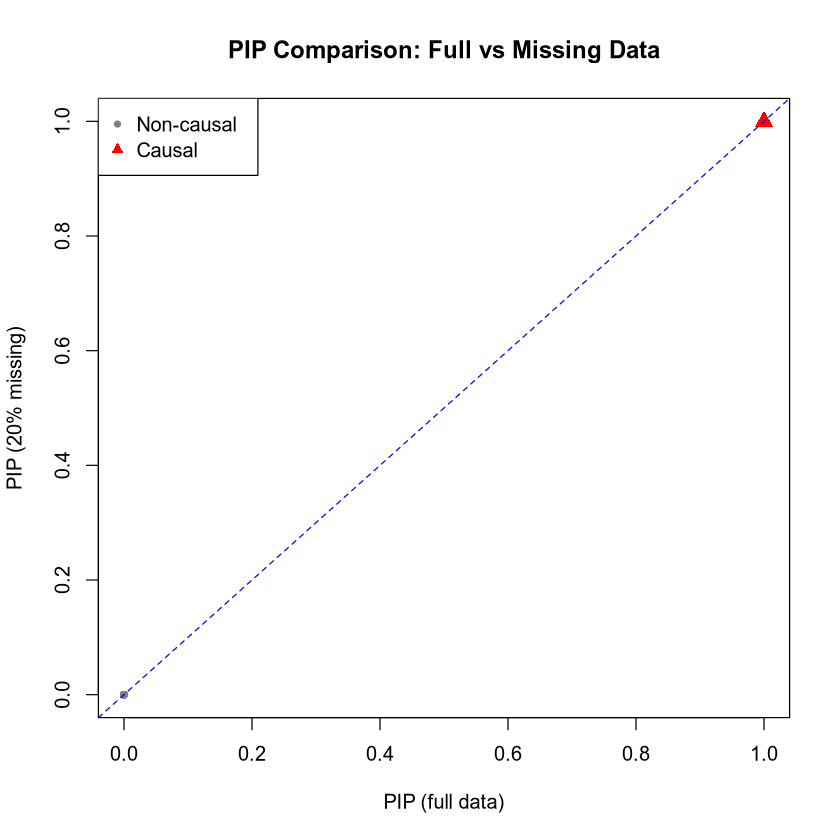

In [8]:
# PIP comparison
cat("PIP correlation between full and missing data fits:",
    cor(fit_full$pip, fit_miss$pip), "\n\n")

cat("PIPs at causal variables:\n")
cat(sprintf("%10s %10s %10s\n", "Variable", "Full", "Missing"))
for (j in causal) {
  cat(sprintf("%10d %10.4f %10.4f\n", j, fit_full$pip[j], fit_miss$pip[j]))
}

# Overlay PIP plot
plot(fit_full$pip, fit_miss$pip,
     xlab = "PIP (full data)", ylab = "PIP (20% missing)",
     main = "PIP Comparison: Full vs Missing Data",
     pch = 20, col = "gray50")
points(fit_full$pip[causal], fit_miss$pip[causal],
       pch = 17, col = "red", cex = 1.5)
abline(0, 1, col = "blue", lty = 2)
legend("topleft", legend = c("Non-causal", "Causal"),
       pch = c(20, 17), col = c("gray50", "red"))

## 7. ELBO Convergence

The ELBO should be monotonically non-decreasing across iterations.

ELBO is non-decreasing: TRUE 


Minimum ELBO change: 0.0007653567 


Final ELBO: -845.3196 


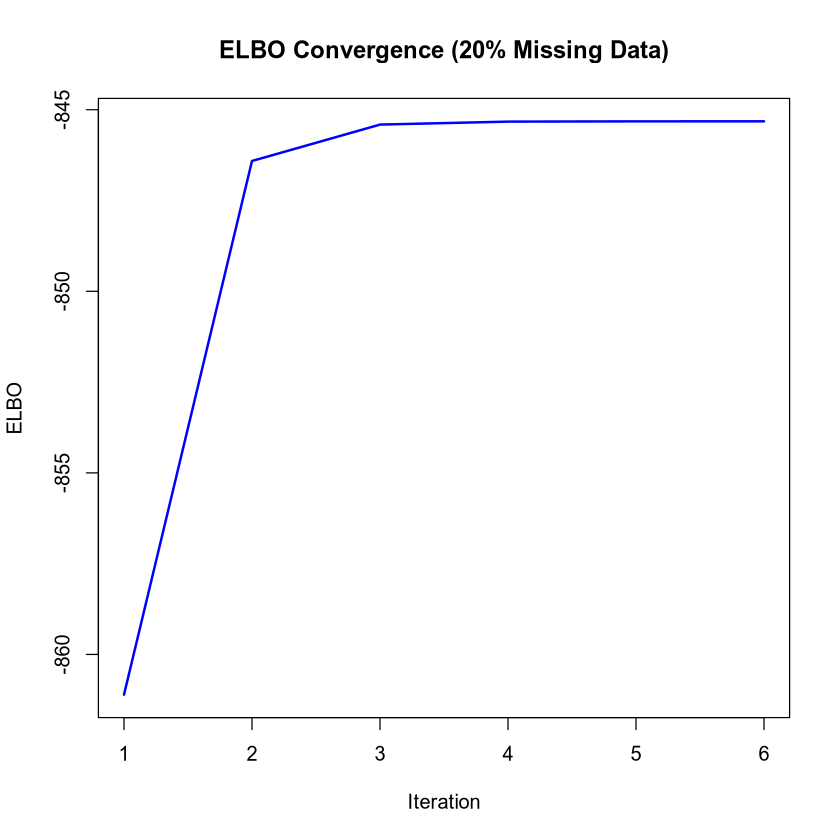

In [9]:
plot(fit_miss$elbo, type = "l", col = "blue", lwd = 2,
     xlab = "Iteration", ylab = "ELBO",
     main = "ELBO Convergence (20% Missing Data)")

# Check monotonicity
diffs <- diff(fit_miss$elbo)
cat("ELBO is non-decreasing:", all(diffs >= -1e-6), "\n")
cat("Minimum ELBO change:", min(diffs), "\n")
cat("Final ELBO:", tail(fit_miss$elbo, 1), "\n")

## 8. Sensitivity to Missingness Rate

Compare results at 5%, 20%, and 50% MCAR.

miss_rate =    0%: PIP correlation with full = 1.0000
miss_rate =    5%: PIP correlation with full = 1.0000
miss_rate =   20%: PIP correlation with full = 1.0000


Warning message in value[[3L]](cond):
“flash failed; using pairwise covariance: The data matrix must not have any rows or columns whose entries are either identically zero or all missing.”


miss_rate =   50%: PIP correlation with full = 0.8157


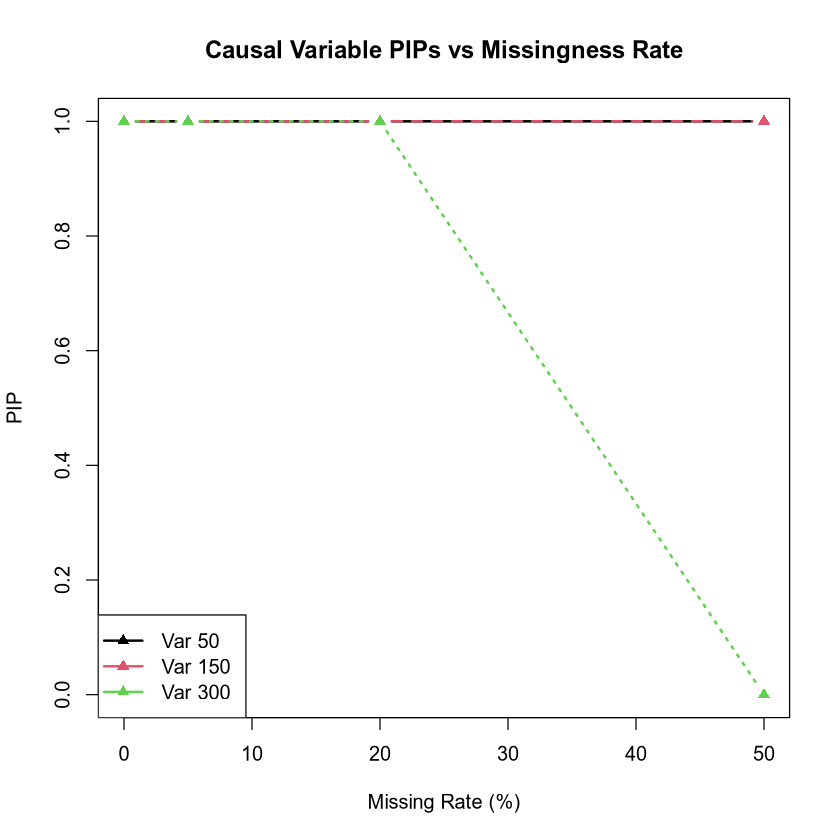

In [10]:
miss_rates <- c(0, 0.05, 0.20, 0.50)
pip_results <- list()

for (mr in miss_rates) {
  set.seed(42)
  Y_tmp <- Y_full
  if (mr > 0) {
    mask <- matrix(runif(N * R) < mr, N, R)
    Y_tmp[mask] <- NA
  }

  fit_tmp <- mvsusie_core(X, Y_tmp, L = 5,
                          prior_variance = prior_V,
                          estimate_residual_variance = FALSE,
                          estimate_prior_variance = TRUE,
                          compute_objective = TRUE,
                          max_iter = 100, verbosity = 0)
  pip_results[[as.character(mr)]] <- fit_tmp$pip
  cat(sprintf("miss_rate = %4.0f%%: PIP correlation with full = %.4f\n",
              mr * 100, cor(pip_results[["0"]], fit_tmp$pip)))
}

# Plot PIPs at causal variables across missingness rates
causal_pips <- sapply(pip_results, function(p) p[causal])
matplot(miss_rates * 100, t(causal_pips), type = "b", pch = 17,
        xlab = "Missing Rate (%)", ylab = "PIP",
        main = "Causal Variable PIPs vs Missingness Rate",
        col = 1:L, lwd = 2, ylim = c(0, 1))
legend("bottomleft", legend = paste("Var", causal),
       col = 1:L, pch = 17, lwd = 2)

## 9. R vs Rcpp Benchmark

Compare the pure-R reference implementation against the Armadillo C++
implementation for imputation speed.

In [11]:
# Prepare data for benchmarking
set.seed(42)
Y_bench <- Y_full
miss_mask_bench <- matrix(runif(N * R) < 0.2, N, R)
Y_bench[miss_mask_bench] <- 0
mu_bench <- matrix(rnorm(N * R, sd = 0.5), N, R)
Vinv_bench <- solve(V_true)

miss_info_bench <- mvsusieR:::extract_missing_patterns(
  matrix(miss_mask_bench, N, R))
pc_bench <- mvsusieR:::precompute_pattern_cache(Vinv_bench,
                                                 miss_info_bench$patterns)

# Benchmark
n_reps <- 50
t_r <- system.time(for (i in seq_len(n_reps)) {
  mvsusieR:::impute_missing_Y(Y_bench, mu_bench, Vinv_bench,
                               miss_info_bench, pc_bench, version = "R")
})[[3]]

t_rcpp <- system.time(for (i in seq_len(n_reps)) {
  mvsusieR:::impute_missing_Y(Y_bench, mu_bench, Vinv_bench,
                               miss_info_bench, pc_bench, version = "Rcpp")
})[[3]]

cat(sprintf("R implementation:    %.4f sec per call\n", t_r / n_reps))
cat(sprintf("Rcpp implementation: %.4f sec per call\n", t_rcpp / n_reps))
cat(sprintf("Speedup: %.1fx\n", t_r / t_rcpp))

# Verify identical results
res_r <- mvsusieR:::impute_missing_Y(Y_bench, mu_bench, Vinv_bench,
                                      miss_info_bench, pc_bench, version = "R")
res_rcpp <- mvsusieR:::impute_missing_Y(Y_bench, mu_bench, Vinv_bench,
                                         miss_info_bench, pc_bench, version = "Rcpp")
cat(sprintf("Max absolute difference: %.2e\n",
            max(abs(res_r$Y - res_rcpp$Y))))

R implementation:    0.0001 sec per call


Rcpp implementation: 0.0001 sec per call


Speedup: 1.0x


Max absolute difference: 2.22e-16
